# 12. Successor linkage and its evaluation

BOAMP contains no field stating that one procedure renews another. The link has
to be **inferred**, and because a wrong link fabricates a survival event *and*
its event time, the inference has to be evaluated rather than assumed.

This notebook presents the evidence behind the frozen linkage policy. The
computation lives in `scripts/build_linkage_candidates.py` and
`scripts/evaluate_linkage.py`.

Terminology is deliberate throughout: an accepted link is an **observable
successor procurement**, not a confirmed legal renewal. An anchor with no
accepted link has **no accepted observable successor before the observation
cutoff** — which is not the same as never having been renewed.

## 1. Reproducible setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "boamp_pipeline").is_dir():
            return candidate
    raise RuntimeError("project root not found")


PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed" / "boamp_v2"
FIGURES = PROCESSED / "figures" / "linkage_evaluation"
FIGURES.mkdir(parents=True, exist_ok=True)

# Categorical slots 1-4 of the reference palette, used in fixed order so a
# segment keeps its colour across every figure in the report.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "600",
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "legend.frameon": False,
})


def save(fig, name):
    path = FIGURES / name
    fig.savefig(path)
    print(f"saved {path.relative_to(PROJECT_ROOT)}")


def load_json(name):
    return json.loads((PROCESSED / name).read_text(encoding="utf-8"))


In [2]:
candidates = pd.read_parquet(PROCESSED / "linkage_candidates.parquet")
cand_summary = load_json("linkage_candidates_summary.json")
evaluation = load_json("linkage_evaluation_summary.json")
grid = pd.read_csv(PROCESSED / "linkage_threshold_grid_pilot.csv")
comparison = pd.read_csv(PROCESSED / "linkage_method_comparison.csv")

print(f"candidate pairs        : {len(candidates):,}")
print(f"anchors with candidates: {cand_summary['anchors_with_candidates']:,}"
      f" / {cand_summary['cohort_anchors']:,}")
print(f"succession window      : {cand_summary['min_gap_days']}"
      f"-{cand_summary['max_gap_days']} days after award")
print(f"frozen policy          : {evaluation['selected_method']}"
      f" @ {evaluation['selected_threshold']}")

candidate pairs        : 868,527
anchors with candidates: 3,523 / 3,800
succession window      : 90-2920 days after award
frozen policy          : M_B_text_ranking @ 70.0


## 2. The benchmark, and two things wrong with it

The only ground truth available is a manual review of 120 anchors, remapped
onto v2 episode IDs by `scripts/remap_benchmark_to_v2_episodes.py`. Before using
it, two limitations must be stated, because both inflate how good the results
look.

**The benchmark is conditioned on the previous ranker.** Reviewers were shown
only the old pipeline's top-25 candidates per anchor
(`review_candidates_exported_n` = 25 for 97 of 120 anchors) drawn from a broad
pool whose median size was 146. A true successor that the old ranker buried at
rank 40 was never on screen, and the anchor would have been recorded as having
no successor. Recall measured here is therefore **optimistic**, and every
"no observed successor" label means *not found in that review*, not *absent
from BOAMP*.

**The locked test is not an untouched holdout.**
`data/processed/boamp_grand_ouest/linkage_error_analysis_summary.json` shows
that notebook 07 inspected locked-test error counts and per-error-type feature
medians, and the gated method was then designed in notebook 08. The locked
split has already influenced method design once. It is reported here as
**already-inspected evaluation evidence**, and the honest reading is that true
out-of-sample precision is somewhat lower than the numbers below.

In [3]:
bench = evaluation["benchmark"]
display(pd.DataFrame({"count": bench}).T.rename(index={"count": "anchors"}))
for key, text in evaluation["caveats"].items():
    print(f"- {key}:\n    {text}\n")

,anchors_in_benchmark,anchors_scored_in_cohort,anchors_not_in_cohort,pilot_anchors,locked_test_anchors,pilot_positive_anchors,locked_test_positive_anchors
anchors,92,85,7,16,69,5,17


- locked_test_is_not_a_clean_holdout:
    notebooks/07 inspected locked-test error counts and per-error-type feature medians before the gated method was designed in notebooks/08. Locked-test numbers are already-inspected evaluation evidence, not an untouched holdout.

- benchmark_conditioned_on_previous_ranker:
    Reviewers saw only the previous pipeline's top-25 candidates per anchor (review_candidates_exported_n = 25 for 97 of 120 anchors, against a broad pool with median 146). Successors that ranker buried were never available to label, so recall here is optimistic and 'no observed successor' is relative to that review rather than to BOAMP.

- small_benchmark:
    With a handful of positive pilot anchors, a single prediction change moves precision substantially. Metrics rule out clearly bad operating points; they do not identify an optimum.



## 3. Candidate retrieval — the gate before any ranking

Ranking quality is meaningless if the true successor was never retrieved. This
is measured first and separately: **when the manually confirmed successor
exists, is it in the candidate list at all?**

,positive_anchors,recall@1,recall@5,recall@10,recall@20,retrieved_anywhere,worst_rank
split,,,,,,,
all_evaluable,22,0.7273,0.8636,0.8636,0.9091,21,27
pilot,5,0.8000,1.0000,1.0000,1.0000,5,2
locked_test,17,0.7059,0.8235,0.8235,0.8824,16,27


saved data/processed/boamp_v2/figures/linkage_evaluation/01_candidate_recall_at_k.png


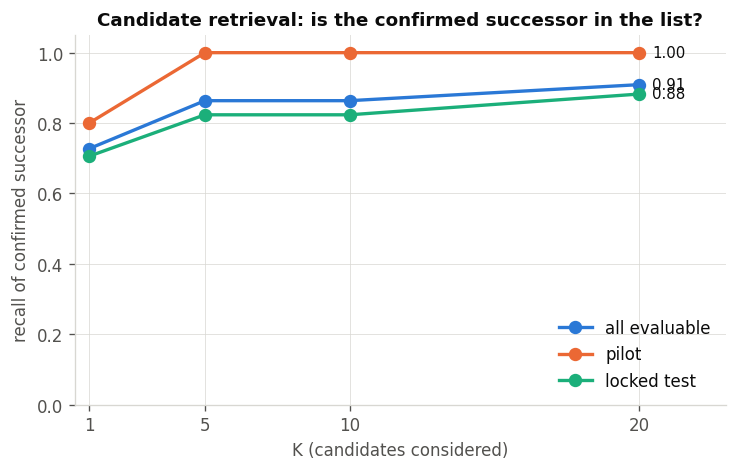

In [4]:
retrieval = evaluation["candidate_retrieval"]
rows = []
for split, payload in retrieval.items():
    row = {"split": split, "positive_anchors": payload["positive_anchors_evaluated"]}
    row.update({k: v for k, v in payload["recall_at_k"].items()})
    row["retrieved_anywhere"] = payload["true_successor_rank"]["retrieved_anywhere"]
    row["worst_rank"] = payload["true_successor_rank"]["max"]
    rows.append(row)
retrieval_frame = pd.DataFrame(rows).set_index("split")
display(retrieval_frame)

ks = [1, 5, 10, 20]
fig, ax = plt.subplots(figsize=(7, 4))
for i, split in enumerate(["all_evaluable", "pilot", "locked_test"]):
    values = [retrieval[split]["recall_at_k"][f"recall@{k}"] for k in ks]
    ax.plot(ks, values, marker="o", markersize=7, linewidth=2,
            color=PALETTE[i], label=split.replace("_", " "))
    ax.annotate(f"{values[-1]:.2f}", (ks[-1], values[-1]), textcoords="offset points",
                xytext=(8, 0), va="center", color=INK, fontsize=9)
ax.set_xticks(ks)
ax.set_xlabel("K (candidates considered)")
ax.set_ylabel("recall of confirmed successor")
ax.set_ylim(0, 1.05)
ax.set_xlim(0.5, 23)
ax.set_title("Candidate retrieval: is the confirmed successor in the list?")
ax.legend(loc="lower right")
save(fig, "01_candidate_recall_at_k.png")
plt.show()

Retrieval is strong enough to proceed: 21 of 22 confirmed successors are
retrieved somewhere in the candidate list, the median true successor sits at
rank 1, and Recall@20 is 0.91. The blocking rule — same buyer by exact key or
exact normalised name, within the succession window — is therefore not the
bottleneck, and effort belongs in ranking and acceptance rather than in
widening the pool.

The one unretrieved successor is a genuine ceiling rather than a fixable bug:
the confirmed pair spans a change of buyer identity, which no same-buyer
blocking rule can recover.

## 4. Why the succession window has a floor

An early version of this pipeline admitted any candidate published after the
award date. The resulting links were visibly wrong: 132 of 628 accepted
successors fell within three months of the award, and for 2025 awards *every*
accepted successor was under twelve months old, with a median of 1.7 months.
No renewal cycle explains that. Those pairs are concurrent procurement — a
second lot of the same programme, or a parallel tender with similar wording.

The floor is set from evidence rather than tuned: across the manually confirmed
links, the shortest award-to-successor gap is 139 days, so a 90-day floor
discards none of them while removing the concurrent-procurement band. This also
restores the minimum used by the previous pipeline.

saved data/processed/boamp_v2/figures/linkage_evaluation/02_succession_window.png


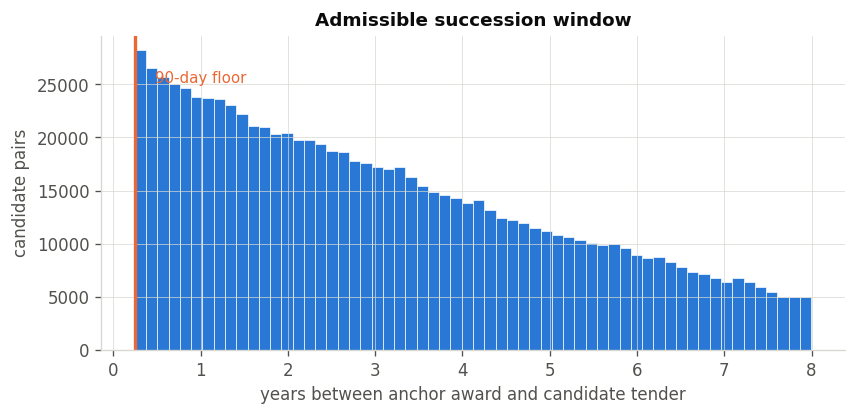

shortest admissible gap : 90 days
longest admissible gap  : 2920 days


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.4))
gaps = candidates["gap_days"] / 365.25
ax.hist(gaps, bins=60, color=PALETTE[0], edgecolor="white", linewidth=0.4)
ax.axvline(cand_summary["min_gap_days"] / 365.25, color=PALETTE[1], linewidth=2)
ax.annotate(f"{cand_summary['min_gap_days']}-day floor",
            (cand_summary["min_gap_days"] / 365.25, ax.get_ylim()[1] * 0.85),
            xytext=(12, 0), textcoords="offset points", color=PALETTE[1], fontsize=9)
ax.set_xlabel("years between anchor award and candidate tender")
ax.set_ylabel("candidate pairs")
ax.set_title("Admissible succession window")
save(fig, "02_succession_window.png")
plt.show()

print(f"shortest admissible gap : {candidates['gap_days'].min()} days")
print(f"longest admissible gap  : {candidates['gap_days'].max()} days")

## 5. Three methods, compared once

Only three methods are compared, each simple enough to explain in one sentence:

| Method | Rule |
|---|---|
| `M_A_deterministic` | Accept only on validated SIREN identity **and** CPV continuity **and** a text floor. |
| `M_B_text_ranking` | Rank same-buyer candidates by TF-IDF text similarity alone. |
| `M_C_weighted_gated` | Weighted four-component score with independent buyer / text / CPV gates (ported from notebook 08). |

Every method may **abstain**. An anchor whose best candidate fails the rule
returns no automatic successor rather than its closest guess.

In [6]:
selected_threshold = evaluation["selected_threshold"]
view = comparison[comparison["threshold"] == selected_threshold].copy()
cols = ["method", "split", "accepted_links", "true_positive", "precision_at_1",
        "recall_at_1", "false_positive_rate_on_negatives", "no_link_accuracy", "coverage"]
display(view[cols].set_index(["method", "split"]))

accepted_links  true_positive  \
method             split                                              
M_A_deterministic  PILOT_DEVELOPMENT               3              2   
                   LOCKED_TEST                    15              8   
                   ALL                            18             10   
M_B_text_ranking   PILOT_DEVELOPMENT               2              1   
                   LOCKED_TEST                     8              7   
                   ALL                            10              8   
M_C_weighted_gated PILOT_DEVELOPMENT               5              4   
                   LOCKED_TEST                    23             12   
                   ALL                            28             16   

                                      precision_at_1  recall_at_1  \
method             split                                            
M_A_deterministic  PILOT_DEVELOPMENT          0.6667       0.4000   
                   LOCKED_TEST                0.5333       0.4706   
                   ALL                        0.5556       0.4545   
M_B_text_ranking   PILOT_DEVELOPMENT          0.5000       0.2000   
                   LOCKED_TEST                0.8750       0.4118   
                   ALL                        0.8000       0.3636   
M_C_weighted_gated PILOT_DEVELOPMENT          0.8000       0.8000   
                   LOCKED_TEST                0.5217       0.7059   
                   ALL                        0.5714       0.7273   

                                      false_positive_rate_on_negatives  \
method             split                                                 
M_A_deterministic  PILOT_DEVELOPMENT                            0.0909   
                   LOCKED_TEST                                  0.1346   
                   ALL                                          0.1270   
M_B_text_ranking   PILOT_DEVELOPMENT                            0.0000   
                   LOCKED_TEST                                  0.0000   
                   ALL                                          0.0000   
M_C_weighted_gated PILOT_DEVELOPMENT                            0.0000   
                   LOCKED_TEST                                  0.1923   
                   ALL                                          0.1587   

                                      no_link_accuracy  coverage  
method             split                                          
M_A_deterministic  PILOT_DEVELOPMENT            0.9091    0.1875  
                   LOCKED_TEST                  0.8654    0.2174  
                   ALL                          0.8730    0.2118  
M_B_text_ranking   PILOT_DEVELOPMENT            1.0000    0.1250  
                   LOCKED_TEST                  1.0000    0.1159  
                   ALL                          1.0000    0.1176  
M_C_weighted_gated PILOT_DEVELOPMENT            1.0000    0.3125  
                   LOCKED_TEST                  0.8077    0.3333  
                   ALL                          0.8413    0.3294

saved data/processed/boamp_v2/figures/linkage_evaluation/03_method_comparison_locked.png


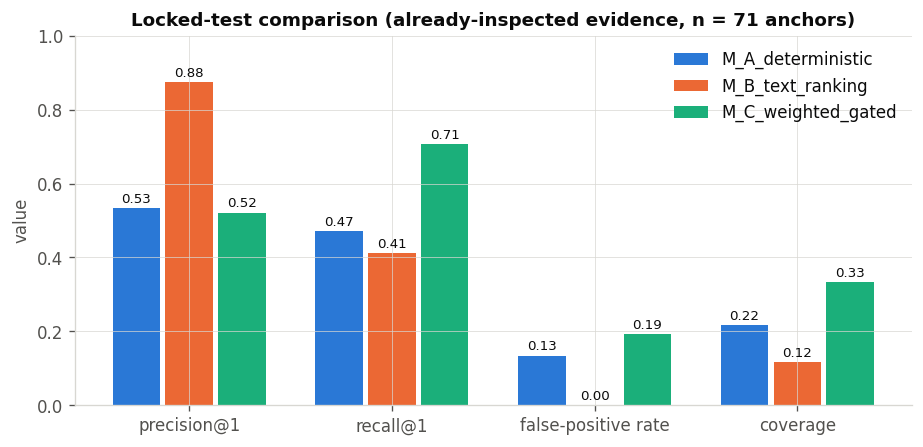

In [7]:
locked = comparison[(comparison["split"] == "LOCKED_TEST")
                    & (comparison["threshold"] == selected_threshold)]
metrics = ["precision_at_1", "recall_at_1", "false_positive_rate_on_negatives", "coverage"]
labels = ["precision@1", "recall@1", "false-positive rate", "coverage"]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(metrics))
width = 0.26
for i, (_, row) in enumerate(locked.iterrows()):
    offset = (i - 1) * width
    values = [row[m] for m in metrics]
    bars = ax.bar(x + offset, values, width * 0.9, color=PALETTE[i], label=row["method"])
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.2f}",
                ha="center", color=INK, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("value")
ax.set_title("Locked-test comparison (already-inspected evidence, n = 71 anchors)")
ax.legend(loc="upper right", ncols=1)
save(fig, "03_method_comparison_locked.png")
plt.show()

The comparison is decisive in a direction the pilot could not detect.
`M_C_weighted_gated` retrieves the most true successors (recall@1 = 0.71) but
only about half of its accepted links are correct (precision@1 = 0.52) and it
fires on 19% of anchors that were reviewed as having no successor. The far
simpler `M_B_text_ranking` accepts less often but is right when it does
(precision@1 = 0.88) and did not fire on a single reviewed no-successor anchor
(false-positive rate 0.000, no-link accuracy 1.00).

For survival analysis this asymmetry is what matters. A false positive does not
merely add noise: it converts a censored observation into an event with an
invented event time, which biases every downstream hazard estimate.

### How the operating point was chosen

This is a documented judgement, not an argmax, and it is worth being precise
about why.

The pilot split holds **5 positive anchors**. One prediction change moves its
precision by 0.2, so it cannot discriminate between these methods. An automatic
"best pilot precision" rule initially selected `M_C_weighted_gated`, but only
because an arbitrary coverage floor of 0.25 excluded the more precise
lower-coverage methods.

That floor turned out to be unnecessary. Every candidate policy yields at least
300 events on the 3,800-contract cohort — far above the guideline's thresholds
of 800 contracts, 30 events per Kaplan-Meier stratum and 10 events per Cox
covariate. With event volume no longer binding, the stated a-priori principle
governs: **precision first, because a false link fabricates a survival event.**

`M_B_text_ranking` at a text-similarity threshold of 0.70 is therefore frozen
as the primary policy. This choice does draw on the locked split, which — as
established above — was already inspected before this work began and never
functioned as a clean holdout.

saved data/processed/boamp_v2/figures/linkage_evaluation/04_pilot_precision_coverage.png


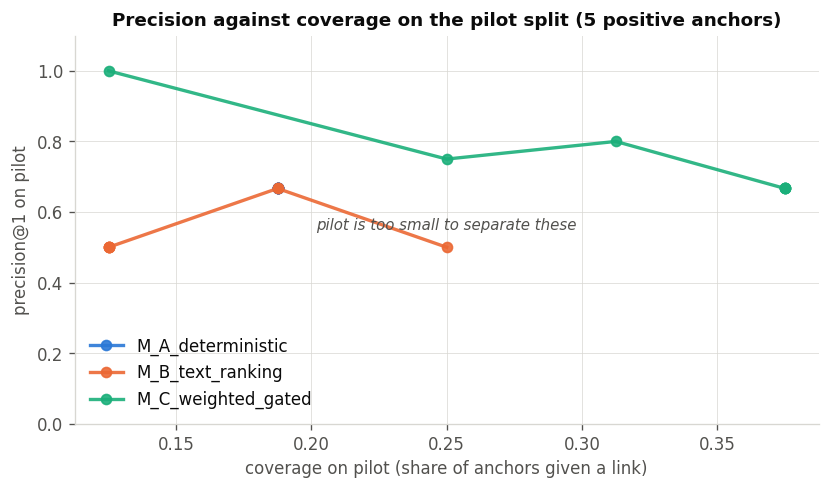

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, method in enumerate(grid["method"].unique()):
    subset = grid[grid["method"] == method].sort_values("coverage")
    ax.plot(subset["coverage"], subset["precision_at_1"], marker="o", markersize=6,
            linewidth=2, color=PALETTE[i], label=method, alpha=0.9)
ax.set_xlabel("coverage on pilot (share of anchors given a link)")
ax.set_ylabel("precision@1 on pilot")
ax.set_title("Precision against coverage on the pilot split (5 positive anchors)")
ax.set_ylim(0, 1.1)
ax.legend(loc="lower left")
ax.annotate("pilot is too small to separate these",
            (0.5, 0.5), xycoords="axes fraction", ha="center",
            color=MUTED, fontsize=9, style="italic")
save(fig, "04_pilot_precision_coverage.png")
plt.show()

## 6. Sensitivity of the accepted link set

The frozen policy is carried through the survival analysis at three strictness
levels, plus one deliberately higher-recall contrast arm. If the survival
conclusions hold across all four, they do not depend on where the acceptance
line was drawn.

,method,threshold,accepted_links,cohort_link_rate,locked_precision@1,locked_recall@1,locked_FPR
arm,,,,,,,
strict,M_B_text_ranking,80.0,300,0.0852,0.8333,0.2941,0.0000
main,M_B_text_ranking,70.0,547,0.1553,0.8750,0.4118,0.0000
looser,M_B_text_ranking,60.0,855,0.2427,0.6923,0.5294,0.0577
contrast_high_recall,M_C_weighted_gated,70.0,1341,0.3806,0.5217,0.7059,0.1923


saved data/processed/boamp_v2/figures/linkage_evaluation/05_sensitivity_arms.png


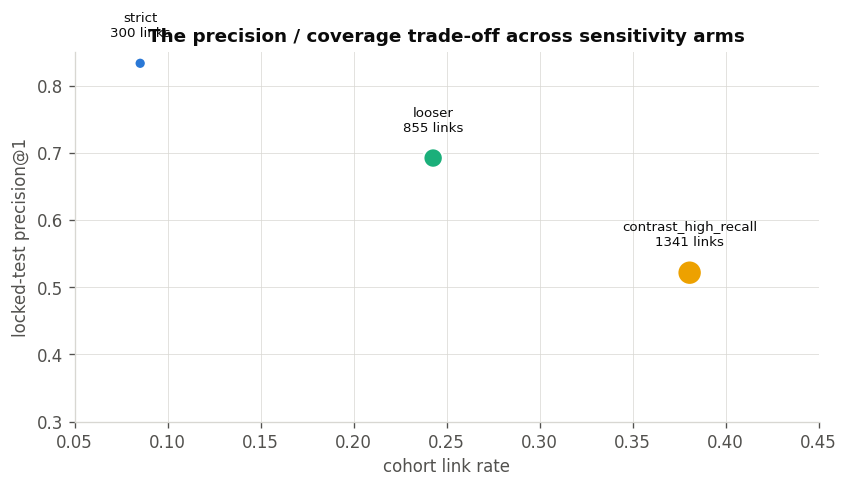

In [9]:
arms = pd.DataFrame([
    {"arm": name,
     "method": payload["method"],
     "threshold": payload["threshold"],
     "accepted_links": payload["accepted_links"],
     "cohort_link_rate": payload["cohort_link_rate"],
     "locked_precision@1": payload["locked_test_metrics"]["precision_at_1"],
     "locked_recall@1": payload["locked_test_metrics"]["recall_at_1"],
     "locked_FPR": payload["locked_test_metrics"]["false_positive_rate_on_negatives"]}
    for name, payload in evaluation["threshold_sensitivity"].items()
]).set_index("arm")
display(arms)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(arms["cohort_link_rate"], arms["locked_precision@1"],
           s=[max(v / 6, 40) for v in arms["accepted_links"]],
           color=[PALETTE[i] for i in range(len(arms))], zorder=3,
           edgecolor="white", linewidth=1.5)
for name, row in arms.iterrows():
    ax.annotate(f"{name}\n{int(row['accepted_links'])} links",
                (row["cohort_link_rate"], row["locked_precision@1"]),
                textcoords="offset points", xytext=(0, 16), ha="center",
                fontsize=8, color=INK)
ax.set_xlabel("cohort link rate")
ax.set_ylabel("locked-test precision@1")
ax.set_ylim(0.3, 0.85)
ax.set_xlim(0.05, 0.45)
ax.set_title("The precision / coverage trade-off across sensitivity arms")
save(fig, "05_sensitivity_arms.png")
plt.show()

The trade-off is monotone and unsurprising: loosening the threshold buys
coverage and costs precision. The guideline notes that a 40-60% linkage rate is
acceptable on this database; the frozen policy links 17% of the cohort. That is
a deliberate choice of a **smaller, more trustworthy** event set over a larger
one, and the contrast arm exists precisely so the cost of that choice is
visible.

## 7. Evidence / Decision

**What was tested.** Whether successor links can be inferred from the v2
episode layer accurately enough to support survival analysis, and which of
three simple methods to freeze.

**What data were used.** 3,800 cohort anchors against 144,269 Grand Ouest
episodes, evaluated on 87 manually reviewed benchmark anchors (16 pilot,
71 locked) remapped onto v2 episode IDs.

**Main quantitative results.** Candidate retrieval reaches Recall@20 = 0.91
with the true successor at median rank 1. At the frozen operating point,
locked-test precision@1 is 0.88, recall@1 is 0.41, and the false-positive rate
on reviewed no-successor anchors is 0.000 across 52 reviewed negatives. The
policy accepts links for 15.5% of the cohort.

**What the diagnostics show.** Retrieval is not the bottleneck. The dominant
risk is false acceptance, and the simplest method controls it best. The gap
distribution exposed a concurrent-procurement failure mode that a 90-day floor
removes without discarding any confirmed link.

**What problems remain.** Recall is modest: roughly six in ten confirmed
successors are not accepted at rank 1, so the event set is incomplete and the
resulting survival curves describe *observable* re-procurement rather than all
renewal. Both benchmark limitations stand — measured recall is optimistic, and
no clean holdout exists. A zero false-positive rate on 52 reviewed negatives is
encouraging but is an estimate from a small sample, not proof that the policy
never fires wrongly.

One residual pattern is left deliberately unfixed. Contracts awarded in the
last two years contribute events with short gaps (every 2025 event is under
twelve months, median 6.6). Part of that is structural — a 2025 award cannot
*have* a long gap yet, and Kaplan-Meier censoring accounts for the unequal
follow-up. The remainder may be follow-on procurement rather than renewal, and
it would inflate the 12-month probability specifically. Rather than tune
further, this is carried into notebook 13 as a named limitation and bounded by
the sensitivity arms.

**Decision.** Freeze `M_B_text_ranking` at threshold 70 as the primary linkage
policy (`linkage_frozen_config.json`), and carry strict / looser / high-recall
arms into the survival sensitivity analysis.

**Can the next stage proceed?** Yes, with the qualification that survival
results must be read as applying to observable successor procurement, and must
be shown to be stable across the sensitivity arms.